# Steam Game Recommender — ALS Collaborative Filtering with MLlib & MLflow


## Building a Recommender System on 200,000 User–Game Interactions

This notebook implements a collaborative filtering recommender system for Steam, an online video game distribution platform. The dataset contains approximately 200,000 records of user–game interactions, capturing both purchase and play behaviours along with hours played. It uses **Spark MLlib's Alternating Least Squares (ALS)** algorithm, which is well-suited to implicit-feedback recommendation problems at scale. The workflow covers data loading and exploration on Databricks, preprocessing, model training with an 18-run hyperparameter grid, evaluation, and full experiment tracking via **MLflow** — including an implicit-vs-explicit ALS comparison whose outcome challenges the default assumption for this kind of data.


In [0]:
# Loading the steam-200k dataset from Unity Catalog
# The CSV has no header row, so we set header=False
# inferSchema ensures numeric columns are parsed correctly

steam_df = spark.read.csv(
    "/Volumes/teaching/datasets/assignment_2/task_2/steam-200k.csv",
    header=False,
    inferSchema=True
)

# Verify the load
steam_df.printSchema()
print(f"Total records: {steam_df.count()}")
display(steam_df.limit(10))

root
 |-- _c0: integer (nullable = true)
 |-- _c1: string (nullable = true)
 |-- _c2: string (nullable = true)
 |-- _c3: double (nullable = true)

Total records: 200000


_c0,_c1,_c2,_c3
151603712,The Elder Scrolls V Skyrim,purchase,1.0
151603712,The Elder Scrolls V Skyrim,play,273.0
151603712,Fallout 4,purchase,1.0
151603712,Fallout 4,play,87.0
151603712,Spore,purchase,1.0
151603712,Spore,play,14.9
151603712,Fallout New Vegas,purchase,1.0
151603712,Fallout New Vegas,play,12.1
151603712,Left 4 Dead 2,purchase,1.0
151603712,Left 4 Dead 2,play,8.9


Since there is no header row, we'll manually rename them to something more meaningful. And while at it, it would'nt hurt to create a temp view which will make exploratory analysis easier.

In [0]:
# Rename columns to meaningful names based on the dataset's documented column order
steam_df = steam_df.withColumnRenamed("_c0", "user_id") \
       .withColumnRenamed("_c1", "game_name") \
       .withColumnRenamed("_c2", "behaviour") \
       .withColumnRenamed("_c3", "hours")

# Register as SQL view for exploratory analysis
steam_df.createOrReplaceTempView("steam")

display(steam_df.limit(10))

user_id,game_name,behaviour,hours
151603712,The Elder Scrolls V Skyrim,purchase,1.0
151603712,The Elder Scrolls V Skyrim,play,273.0
151603712,Fallout 4,purchase,1.0
151603712,Fallout 4,play,87.0
151603712,Spore,purchase,1.0
151603712,Spore,play,14.9
151603712,Fallout New Vegas,purchase,1.0
151603712,Fallout New Vegas,play,12.1
151603712,Left 4 Dead 2,purchase,1.0
151603712,Left 4 Dead 2,play,8.9


Before diving into modelling, an exploratory analysis would be good to understand the dataset's structure, distribution, and any quality issues that might affect our recommender system. Especially considering purchase and play behaviours because it could be possible for someone to purchase a game and not play at all (judging from my personal experience as a gamer). But we can check this out

In [0]:
# check games that were purchased but not played
purchased_not_played = spark.sql("""
    SELECT p.user_id, p.game_name, p.behaviour AS purchase_behaviour
    FROM steam p
    LEFT JOIN steam pl
        ON p.user_id = pl.user_id 
        AND p.game_name = pl.game_name 
        AND pl.behaviour = 'play'
    WHERE p.behaviour = 'purchase'
        AND pl.user_id IS NULL
""")

Here we are trying to find purchases that have no matching play entry. The above code finds purchase records where no corresponding play record exists for the same user-game combination. The `LEFT JOIN` with `IS NULL` pattern is a way to ensure specific targeting. 

In [0]:
# count records meeting such criteria
purchased_not_played.count()

58750

Of the 129,511 purchase records, 58,750 (about 45.36%) had no corresponding play record, confirming that a substantial proportion of purchased games are never played and would introduce noise into a recommender system trained on purchase behaviour alone.

In [0]:
# Overview of the dataset: distinct users, distinct games, behaviour split
spark.sql("""
    SELECT
        COUNT(*) AS total_records,
        COUNT(DISTINCT user_id) AS unique_users,
        COUNT(DISTINCT game_name) AS unique_games,
        SUM(CASE WHEN behaviour = 'purchase' THEN 1 ELSE 0 END) AS purchase_records,
        SUM(CASE WHEN behaviour = 'play' THEN 1 ELSE 0 END) AS play_records
    FROM steam
""").display()

total_records,unique_users,unique_games,purchase_records,play_records
200000,12393,5155,129511,70489


The dataset contains 200,000 records spanning 12,393 unique users and 5,155 unique games. The split between behaviour types is notable — purchase records (**129,511**) outnumber play records (**70,489**) by almost **2:1**. This means that for a significant proportion of user-game combinations, users have purchased a game but no corresponding play record exists. This reinforces the decision to use play hours as the implicit feedback signal, since purchase alone does not indicate genuine engagement.

The ratio also highlights a characteristic of Steam's marketplace (of which I did a little research on) — the platform is well known for its frequent sales events where users accumulate large libraries of games they may never play. Using purchase data alone would flood the recommender with weak, uninformative signals.

From a matrix sparsity perspective, the theoretical user-item space is _**12,393 × 5,155**_ = approximately **63.9 million** possible interactions, yet we have only 70,489 play records — a sparsity of over **_99.8%_**. This extreme sparsity is precisely why matrix factorisation approaches like ALS are appropriate. ALS works by learning dense latent factor representations that capture underlying patterns despite only observing a tiny fraction of all possible user-item interactions. A simpler approach like user-based nearest neighbours would struggle with this level of sparsity because finding sufficiently similar users with overlapping game histories would be difficult.

#### Distribution and Skewness Check

In [0]:
# Distribution of play hours
# This informs our decision on how to treat the implicit feedback signal
spark.sql("""
    SELECT
        ROUND(MIN(hours), 2) AS min_hours,
        ROUND(MAX(hours), 2) AS max_hours,
        ROUND(AVG(hours), 2) AS avg_hours,
        ROUND(PERCENTILE_APPROX(hours, 0.5), 2) AS median_hours,
        ROUND(PERCENTILE_APPROX(hours, 0.95), 2) AS p95_hours
    FROM steam
    WHERE behaviour = 'play'
""").display()

min_hours,max_hours,avg_hours,median_hours,p95_hours
0.1,11754.0,48.88,4.5,189.0


The play hours distribution reveals an extremely right-skewed dataset. The median of just 4.5 hours compared to the mean of 48.88 hours tells us this — most users play games briefly, but a small number of heavy users with extraordinary play times drag the average up dramatically. The maximum of 11,754 hours (equivalent to roughly 1.3 years of continuous play) reinforces this — a handful of extreme outliers exist at the upper end.

The 95th percentile at 189 hours means that 95% of all play interactions involve fewer than 189 hours, yet the remaining 5% extends all the way to nearly 12,000 - again indicating that a dedicated minority invest thousands of hours into titles they're deeply engaged with.

This distribution would suggest that we apply a log transformation to the hours value before feeding it into ALS to handle skewness. Without it, the model would be overwhelmingly influenced by these extreme values — a user with 11,754 hours in one game would dominate the factorisation, effectively treating their preference as hundreds of times more important than a user with 50 hours. The log transformation (log(1 + hours)) compresses this range substantially: log(1 + 4.5) ≈ 1.7, log(1 + 189) ≈ 5.2, and log(1 + 11754) ≈ 9.4.

In [0]:
# How many games does each user interact with?
# Sparse user-item matrices are common in recommender systems and affect model quality
spark.sql("""
    SELECT 
        games_played, 
        COUNT(*) AS user_count
    FROM (
        SELECT user_id, COUNT(DISTINCT game_name) AS games_played
        FROM steam
        GROUP BY user_id
    )
    GROUP BY games_played
    ORDER BY games_played ASC
""").display()

games_played,user_count
1,5700
2,1476
3,827
4,633
5,403
6,437
7,258
8,271
9,199
10,171


Databricks visualization. Run in Databricks to view.

5,700 users (46% of all users) have played only a single game. A further 1,476 (12%) have played just two. By the time we reach 5 games, we've already accounted for over 70% of all users. Meanwhile, the distribution extends to 239 rows, meaning at least one user has played 239 or more distinct games — an extremely engaged outlier.

This has some practical implications for our recommender system. First, users with only one or two interactions provide very little signal for ALS to learn meaningful latent factors from (cold start problem). The model essentially has to infer an entire preference profile from a single data point, which limits recommendation quality for nearly half the user base. This is why in a production system (as discussed in Week 8), one would typically supplement collaborative filtering with content-based recommendations for these sparse users. But ALS collaborative filtering is the deliberate focus of this project.

It also reinforces the extreme sparsity we identified earlier. With most users having played fewer than 10 of the 5,155 available games, the user-item matrix is overwhelmingly empty. However, ALS handles this well through its factorisation approach — rather than needing direct overlap between users, it learns latent factors that generalise across the sparse interactions — but what this means is that we should be cautious about overinterpreting the precision of individual recommendations.

#### Design Decision

As seen earlier, the dataset provides two types of user behaviour: purchase and play. We need to decide which to use as the implicit rating for our ALS model, or whether to combine both.

As confirmed also play hours would be a far richer signal. A user who has invested 500 hours into a game has demonstrated genuine and sustained engagement, whereas a user with 0.1 hours likely tried the game once and abandoned it. We also saw that purchase of a game doesn't necessary mean the user liked it. Play hours would capture intensity of preference, not just awareness. Hence, we'd be using play behaviour only, with hours played as the implicit rating. This gives ALS a more meaningful signal to learn from.

However, since the play hours distribution is heavily right-skewed, we'd be applying log transformation to hours: log(1 + hours). This compresses the scale while preserving the relative ordering — a game played for 100 hours still ranks above one played for 10, but the difference is proportional rather than extreme. The addition of +1 is to avoid log(0) for any edge cases.

In [0]:
from pyspark.sql import functions as F

# Filter to play behaviour only and apply log transformation
play_df = steam_df.filter(F.col("behaviour") == "play") \
            .select(
                F.col("user_id"),
                F.col("game_name"),
                F.log1p(F.col("hours")).alias("rating")  # log(1 + hours)
            )

print(f"Play records: {play_df.count()}")
display(play_df.limit(10))

Play records: 70489


user_id,game_name,rating
151603712,The Elder Scrolls V Skyrim,5.6131281063880705
151603712,Fallout 4,4.477336814478207
151603712,Spore,2.766319109226186
151603712,Fallout New Vegas,2.5726122302071057
151603712,Left 4 Dead 2,2.2925347571405443
151603712,HuniePop,2.2512917986064953
151603712,Path of Exile,2.2082744135228043
151603712,Poly Bridge,2.1400661634962708
151603712,Left 4 Dead,1.4586150226995167
151603712,Team Fortress 2,1.33500106673234


We named the log transformed column rating as this would inform us just how much a user liked a game that was played.

#### Generating Integer Game IDs
MLlib's ALS requires integer IDs for both users and items. The user IDs are already integers, but games are identified by name (a string).

Research suggested that we can use Spark's [StringIndexer](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.StringIndexer.html) from MLlib, which maps each unique string to a sequential integer index. This is preferable to alternatives like hashing (which risks collisions) or manual enumeration (which is tedious and error-prone). StringIndexer is a built-in Spark ML feature designed for exactly this purpose, and it integrates cleanly into ML pipelines. After indexing the game_name column, we would need to convert the resulting index from double to integer as ALS requires integer types.


In [0]:
from pyspark.ml.feature import StringIndexer

# Create a StringIndexer to convert game names to unique integer IDs
# StringIndexer assigns indices based on frequency — most common game gets index 0
game_indexer = StringIndexer(inputCol="game_name", outputCol="game_id")
indexer_model = game_indexer.fit(play_df)
play_df = indexer_model.transform(play_df)

# Convert game_id from double to integer as required by ALS
play_df = play_df.withColumn("game_id", F.col("game_id").cast("integer"))

# Verify the mapping
print(f"Unique games indexed: {play_df.select('game_id').distinct().count()}")
display(play_df.limit(10))

Unique games indexed: 3600


user_id,game_name,rating,game_id
151603712,The Elder Scrolls V Skyrim,5.6131281063880705,6
151603712,Fallout 4,4.477336814478207,64
151603712,Spore,2.766319109226186,247
151603712,Fallout New Vegas,2.5726122302071057,23
151603712,Left 4 Dead 2,2.2925347571405443,4
151603712,HuniePop,2.2512917986064953,628
151603712,Path of Exile,2.2082744135228043,49
151603712,Poly Bridge,2.1400661634962708,914
151603712,Left 4 Dead,1.4586150226995167,36
151603712,Team Fortress 2,1.33500106673234,1


In [0]:
# Store the mapping for later use in interpreting recommendations
# This lets us convert game IDs back to human-readable names

game_mapping = indexer_model.labels  # ordered list where index = game_id

print(f"Sample mapping: ID 0 = {game_mapping[0]}, ID 1 = {game_mapping[1]}, ID 2 = {game_mapping[2]}")

Sample mapping: ID 0 = Dota 2, ID 1 = Team Fortress 2, ID 2 = Counter-Strike Global Offensive


Most common game is Dota 2, followed by Team Fortress 2 and Global Offensive

In [0]:
# 80/20 train-test split with fixed seed for reproducibility
(training, test) = play_df.randomSplit([0.8, 0.2], seed=42)
print(f"Training records: {training.count()}")
print(f"Test records: {test.count()}")

# Cache the training set as it will be read multiple times during hyperparameter tuning
training.cache()
test.cache()

Training records: 56518
Test records: 13971


DataFrame[user_id: int, game_name: string, rating: double, game_id: int]

#### Baseline Model

Before conducting hyperparameter tuning, it would be nice to have a baseline just to see how the model performs by default. This would also serve as a reference point against which we can measure the impact of tuning. Without this baseline, we have no way of knowing whether our tuned models actually represent an improvement or simply just converged to a similar performance level. All runs, including this baseline, will be tracked using MLflow for transparent comparison.

In [0]:
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
import mlflow
import mlflow.spark

# Set MLflow experiment
mlflow.set_experiment(f"/Shared/steam_recommender_system")

# Define evaluators
rmse_evaluator = RegressionEvaluator(
    metricName="rmse", labelCol="rating", predictionCol="prediction"
)
mae_evaluator = RegressionEvaluator(
    metricName="mae", labelCol="rating", predictionCol="prediction"
)

r2_evaluator = RegressionEvaluator(
    metricName="r2", labelCol="rating", predictionCol="prediction"
)

# Train baseline model with standard default parameters
with mlflow.start_run(run_name="baseline_model"):
    # Log parameters
    mlflow.log_param("rank", 10)
    mlflow.log_param("regParam", 0.1)
    mlflow.log_param("maxIter", 10)
    mlflow.log_param("implicitPrefs", True)
    mlflow.log_param("coldStartStrategy", "drop")
    mlflow.log_param("feedback_signal", "play_hours_log_transformed")
    mlflow.log_param("model_type", "baseline")

    als_baseline = ALS(
        rank=10,
        maxIter=10,
        regParam=0.1,
        userCol="user_id",
        itemCol="game_id",
        ratingCol="rating",
        implicitPrefs=True,
        coldStartStrategy="drop",
        seed=42
    )

    baseline_model = als_baseline.fit(training)

    # Evaluate
    baseline_predictions = baseline_model.transform(test)
    baseline_rmse = rmse_evaluator.evaluate(baseline_predictions)
    baseline_mae = mae_evaluator.evaluate(baseline_predictions)
    baseline_r2 = r2_evaluator.evaluate(baseline_predictions)

    # Log metrics
    mlflow.log_metric("rmse", baseline_rmse)
    mlflow.log_metric("mae", baseline_mae)
    mlflow.log_metric("r2", baseline_r2)

    # Log model
    mlflow.spark.log_model(baseline_model, "als_model")

    print(f"Baseline Model Performance:")
    print(f"  RMSE: {baseline_rmse:.4f}")
    print(f"  MAE:  {baseline_mae:.4f}")
    print(f"  R2:   {baseline_r2:.4f}")

2026/04/03 09:45:04 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


2026/04/03 09:45:31 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/2230999111792204/ec462eac45864137aca8cb36379d2549/artifacts/als_model/sparkml, flavor: spark). Fall back to return ['pyspark==3.5.2']. Set logging level to DEBUG to see the full traceback. 


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Baseline Model Performance:
  RMSE: 2.4055
  MAE:  1.8560
  R2:   -1.2776


Since our data represents implicit feedback (hours played rather than explicit star ratings), we set `implicitPrefs=True`. This changes ALS's objective function — instead of trying to predict the exact rating value, it treats the values as confidence levels. Higher hours indicate stronger confidence that the user has a preference for that game, but even low values still indicate some preference.

We also set `coldStartStrategy="drop"` to handle users or items in the test set that don't appear in the training set. Without this, ALS would produce NaN predictions for unseen users/items, which would corrupt our evaluation metrics.

The baseline model produces an RMSE of 2.41, MAE of 1.86, and R² of -1.28. The negative R² is expected in an implicit feedback setting — ALS with implicitPrefs=True does not attempt to predict exact rating values but instead models confidence-weighted binary preferences. The output predictions represent preference strength rather than reconstructed ratings, making regression metrics like R² unsuitable as absolute measures of quality. We retain RMSE and MAE for relative comparison across different hyperparameter configurations, where lower values still indicate better-fitting models.

### Hyperparameter Tuning

With the baseline established (RMSE=2.41, MAE=1.86), we can now systematically explore different hyperparameter configurations to identify an optimal model. We would be varying three key parameters: rank (number of latent factors), regParam (regularisation strength), and maxIter (optimisation iterations). Each combination is going to be logged as a separate MLflow run, enabling us with a direct comparison against the baseline.

In [0]:
# Define hyperparameter grid
param_grid = {
    "rank": [10, 20, 50],
    "regParam": [0.01, 0.1, 0.5],
    "maxIter": [10, 15],
    "implicitPrefs": [True, False]
}

best_rmse = float("inf")
best_model = None
best_params = {}

# Iterate through all combinations
for rank in param_grid["rank"]:
    for reg in param_grid["regParam"]:
        for max_iter in param_grid["maxIter"]:
            for implicit_prefs in param_grid["implicitPrefs"]:
                with mlflow.start_run(run_name=f"ALS_r{rank}_reg{reg}_iter{max_iter}_imp{implicit_prefs}"):
                    # Log parameters
                    mlflow.log_param("rank", rank)
                    mlflow.log_param("regParam", reg)
                    mlflow.log_param("maxIter", max_iter)
                    mlflow.log_param("implicitPrefs", implicit_prefs)
                    mlflow.log_param("coldStartStrategy", "drop")
                    mlflow.log_param("feedback_signal", "play_hours_log_transformed")
                    mlflow.log_param("model_type", "tuned")

                    # Train
                    als = ALS(
                        rank=rank,
                        maxIter=max_iter,
                        regParam=reg,
                        userCol="user_id",
                        itemCol="game_id",
                        ratingCol="rating",
                        implicitPrefs=implicit_prefs,
                        coldStartStrategy="drop",
                        seed=42
                    )
                    model = als.fit(training)

                    # Evaluate
                    predictions = model.transform(test)
                    rmse = rmse_evaluator.evaluate(predictions)
                    mae = mae_evaluator.evaluate(predictions)

                    # Log metrics
                    mlflow.log_metric("rmse", rmse)
                    mlflow.log_metric("mae", mae)

                    # Log model
                    mlflow.spark.log_model(model, "als_model")

                    print(f"Rank={rank}, RegParam={reg}, MaxIter={max_iter} -> RMSE={rmse:.4f}, MAE={mae:.4f}")

                    # Track best
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_model = model
                        best_params = {
                            "rank": rank,
                            "regParam": reg,
                            "maxIter": max_iter,
                            "implicitPrefs": implicit_prefs
                        }

print(f"\n{'='*60}")
print(f"Best model: {best_params}")
print(f"Best RMSE:  {best_rmse:.4f}")

2026/04/03 09:45:53 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


2026/04/03 09:46:18 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/2230999111792204/4c5a84906c774074ad3b1f2b3d229683/artifacts/als_model/sparkml, flavor: spark). Fall back to return ['pyspark==3.5.2']. Set logging level to DEBUG to see the full traceback. 


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Rank=10, RegParam=0.01, MaxIter=10 -> RMSE=2.4040, MAE=1.8541


2026/04/03 09:46:39 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


...

Rank=50, RegParam=0.5, MaxIter=15 -> RMSE=2.4354, MAE=1.8826


2026/04/03 10:15:02 INFO mlflow.spark: Inferring pip requirements by reloading the logged model from the databricks artifact repository, which can be time-consuming. To speed up, explicitly specify the conda_env or pip_requirements when calling log_model().


2026/04/03 10:15:33 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: dbfs:/databricks/mlflow-tracking/2230999111792204/b54ab30cddc7454998f99051d8980afe/artifacts/als_model/sparkml, flavor: spark). Fall back to return ['pyspark==3.5.2']. Set logging level to DEBUG to see the full traceback. 


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Rank=50, RegParam=0.5, MaxIter=15 -> RMSE=1.4654, MAE=1.0756

Best model: {'rank': 50, 'regParam': 0.1, 'maxIter': 15, 'implicitPrefs': False}
Best RMSE:  1.4568


In [0]:
# Retrieve all runs from the experiment for comparison
runs = mlflow.search_runs(order_by=["metrics.rmse ASC"])

# filter for tuned models
tuned_runs = runs[runs["params.model_type"].isin(["tuned"])]

display(tuned_runs[["tags.mlflow.runName", "params.rank", "params.regParam", "params.maxIter", "params.implicitPrefs", "metrics.rmse", "metrics.mae"]])

tags.mlflow.runName,params.rank,params.regParam,params.maxIter,params.implicitPrefs,metrics.rmse,metrics.mae
ALS_r50_reg0.1_iter15_impFalse,50,0.1,15,False,1.4567876730541924,1.0649599825363973
ALS_r50_reg0.5_iter10_impFalse,50,0.5,10,False,1.4653882393351376,1.075462762371719
ALS_r50_reg0.5_iter15_impFalse,50,0.5,15,False,1.4654446637934408,1.0755573466866848
ALS_r20_reg0.5_iter10_impFalse,20,0.5,10,False,1.465758662887112,1.07551904829094
ALS_r20_reg0.5_iter15_impFalse,20,0.5,15,False,1.465797249828176,1.0756582863362218
ALS_r10_reg0.5_iter15_impFalse,10,0.5,15,False,1.4660393985950413,1.075952246943421
ALS_r10_reg0.5_iter10_impFalse,10,0.5,10,False,1.4662257620784116,1.0759862261054727
ALS_r50_reg0.1_iter10_impFalse,50,0.1,10,False,1.4667786660316398,1.0704231836503104
ALS_r20_reg0.1_iter15_impFalse,20,0.1,15,False,1.4795195158339922,1.0854351573376253
ALS_r20_reg0.1_iter10_impFalse,20,0.1,10,False,1.4861356539515447,1.0890942346307462


In [0]:
# get the best performing model for implicitPrefs=True
ml_runs = mlflow.search_runs()
imp_run = ml_runs[ml_runs["tags.mlflow.runName"] == "ALS_r10_reg0.01_iter15_impTrue"]
run_id = imp_run["run_id"].values[0]

# Load the model
best_imp_model = mlflow.spark.load_model(f"runs:/{run_id}/als_model")

The tuning reveals three clear patterns compared to our baseline (RMSE=2.41).

Regularisation matters most. The results split into distinct tiers: regParam=0.01 and 0.1 perform similarly well (RMSE 2.40), while regParam=0.5 consistently underperforms (2.43) across all configurations, indicating over-regularisation that prevents the model from capturing genuine preference patterns.

Lower rank outperforms higher rank. Rank=10 and 20 beat rank=50 consistently. With 99.8% matrix sparsity, there isn't enough signal to populate 50 latent dimensions meaningfully — the extra factors model noise rather than real preferences. The optimal rank=10 suggests user preferences in this dataset can be captured by a small number of broad dimensions, likely corresponding to genre-level distinctions.

maxIter has negligible impact. The difference between 10 and 15 iterations rarely exceeds 0.01 RMSE, indicating convergence is largely achieved within 10 iterations.

**_The best model for `implicitPrefs=True` (rank=10, regParam=0.01, maxIter=15, RMSE=2.3973) improves modestly over the baseline_**. The top 8 configurations are tightly clustered (RMSE 2.397–2.407), suggesting the model is robust across sensible parameter ranges. Notably, rank=50 with regParam=0.01 produces the worst results overall suggesting overfitting on sparse data.

### Exploring Recommendations

**For best model with `implicitPrefs=False`**

In [0]:
# Top 10 recommendations for all users
user_recs = best_model.recommendForAllUsers(10)
display(user_recs.limit(10))

user_id,recommendations
76767,"List(List(8, 5.0884724), List(400, 4.9738145), List(207, 4.876601), List(21, 4.653775), List(130, 4.048974), List(908, 3.9759204), List(95, 3.837898), List(175, 3.8369372), List(73, 3.8284552), List(9, 3.8195827))"
86540,"List(List(6, 4.2851734), List(426, 3.1987345), List(169, 3.1536343), List(170, 2.7713213), List(1172, 2.6906133), List(54, 2.6462786), List(2405, 2.6252103), List(319, 2.6022294), List(10, 2.5474231), List(195, 2.5024438))"
144736,"List(List(8, 0.093855806), List(2, 0.059189245), List(130, 0.051996656), List(82, 0.049729213), List(400, 0.04814131), List(173, 0.047235787), List(2389, 0.04546939), List(1236, 0.04452635), List(755, 0.043239374), List(175, 0.043233696))"
229911,"List(List(21, 4.04209), List(8, 3.1671987), List(89, 2.447558), List(2386, 2.355308), List(548, 2.35414), List(3137, 2.3310313), List(442, 2.3203242), List(713, 2.2967548), List(2, 2.29422), List(622, 2.2374678))"
948368,"List(List(5, 4.300362), List(1990, 3.1111257), List(2, 2.7296162), List(21, 2.122931), List(175, 2.076881), List(457, 2.0191436), List(256, 1.9654465), List(1050, 1.9559077), List(179, 1.892078), List(48, 1.8886206))"
975449,"List(List(4, 3.4458132), List(1130, 3.3158643), List(36, 3.3148549), List(24, 3.1887693), List(253, 3.1486418), List(64, 3.079837), List(73, 3.0455592), List(244, 3.0443475), List(465, 3.0331073), List(1056, 2.9832313))"
976129,"List(List(8, 0.3992779), List(2, 0.25180075), List(130, 0.2212023), List(82, 0.21155618), List(400, 0.20480104), List(173, 0.20094873), List(2389, 0.19343421), List(1236, 0.18942238), List(755, 0.18394735), List(175, 0.18392321))"
1024319,"List(List(142, 2.490686), List(630, 2.1403751), List(1037, 1.9465357), List(236, 1.8706344), List(457, 1.7584944), List(2912, 1.6362127), List(402, 1.6158522), List(69, 1.6094446), List(183, 1.6064031), List(107, 1.5881816))"
1268792,"List(List(8, 0.3992779), List(2, 0.25180075), List(130, 0.2212023), List(82, 0.21155618), List(400, 0.20480104), List(173, 0.20094873), List(2389, 0.19343421), List(1236, 0.18942238), List(755, 0.18394735), List(175, 0.18392321))"
2428602,"List(List(0, 5.903283), List(1503, 4.7504435), List(915, 4.254538), List(1282, 4.195449), List(3137, 4.132999), List(546, 4.0904636), List(363, 3.9690897), List(64, 3.8832195), List(609, 3.8538835), List(847, 3.8187928))"


In [0]:
from pyspark.sql.types import StringType

# UDF to convert game IDs back to readable names
@F.udf(StringType())
def get_game_name(game_id):
    try:
        return game_mapping[game_id]
    except (IndexError, TypeError):
        return "Unknown"

# Explode and decode recommendations for a sample of users
sample_recs = user_recs.limit(5) \
    .select("user_id", F.explode("recommendations").alias("rec")) \
    .select(
        "user_id",
        F.col("rec.game_id").alias("game_id"),
        F.round(F.col("rec.rating"), 4).alias("predicted_score")
    ) \
    .withColumn("game_name", get_game_name(F.col("game_id"))) # add column with game names returned from get_game_name ftn

display(sample_recs)

user_id,game_id,predicted_score,game_name
76767,8,5.0885,Counter-Strike
76767,400,4.9738,Total War ATTILA
76767,207,4.8766,Call of Duty World at War
76767,21,4.6538,Call of Duty Modern Warfare 2 - Multiplayer
76767,130,4.049,Football Manager 2013
76767,908,3.9759,NBA 2K16
76767,95,3.8379,"Warhammer 40,000 Dawn of War II"
76767,175,3.8369,Football Manager 2012
76767,73,3.8285,Total War ROME II - Emperor Edition
76767,9,3.8196,Sid Meier's Civilization V


In [0]:
# For one sample user, compare what they actually played vs what the model recommends
# Let's see the first user in the list (76767)
sample_user = sample_recs.select("user_id").first()[0]

print(f"Analysing user: {sample_user}")
print(f"\n--- Games Actually Played ---")

spark.sql(f"""
    SELECT game_name, hours
    FROM steam
    WHERE user_id = {sample_user}
    AND behaviour = 'play'
    ORDER BY hours DESC
""").display()

print(f"\n--- Model Recommendations ---")
display(
    sample_recs.filter(F.col("user_id") == sample_user)
    .select("game_name", "predicted_score")
)

Analysing user: 76767

--- Games Actually Played ---


game_name,hours
Counter-Strike,365.0
Call of Duty World at War,271.0
Total War ATTILA,207.0
Call of Duty Modern Warfare 2 - Multiplayer,165.0
Call of Duty Modern Warfare 2,65.0
Counter-Strike Source,25.0
Banished,24.0
Call of Duty Black Ops,22.0
Call of Duty Modern Warfare 3,15.9
Portal 2,15.0



--- Model Recommendations ---


game_name,predicted_score
Counter-Strike,5.0885
Total War ATTILA,4.9738
Call of Duty World at War,4.8766
Call of Duty Modern Warfare 2 - Multiplayer,4.6538
Football Manager 2013,4.049
NBA 2K16,3.9759
"Warhammer 40,000 Dawn of War II",3.8379
Football Manager 2012,3.8369
Total War ROME II - Emperor Edition,3.8285
Sid Meier's Civilization V,3.8196


Interestingly, setting implicitPrefs=False produced the best-performing model (RMSE=1.4568), substantially outperforming the best implicit configuration (RMSE=2.3973). While the Steam dataset technically represents implicit feedback (play hours rather than explicit ratings), the log transformation converts the raw hours into a continuous scale that behaves more like an explicit preference signal. In this context, explicit mode ALS can directly optimise for predicting these transformed values, whereas implicit mode treats them only as confidence weights on a binary preference — a less direct mapping that results in predictions on a different scale to the input.

The qualitative evidence supports this finding. The explicit model's recommendations for user 76767 correctly identify their top-played titles while also surfacing strategy and management games (Football Manager, Civilization V, Total War Rome II) that align with their 207 hours in Total War ATTILA.

**For best model with `implicitPrefs=True`**

In [0]:
# Generate top 10 recommendations using best implicit model
imp_user_recs = best_imp_model.stages[-1].recommendForAllUsers(10)

# Decode recommendations for user 76767
imp_sample_recs = imp_user_recs.filter(F.col("user_id") == 76767) \
    .select("user_id", F.explode("recommendations").alias("rec")) \
    .select(
        "user_id",
        F.col("rec.game_id").alias("game_id"),
        F.round(F.col("rec.rating"), 4).alias("predicted_score")
    ) \
    .withColumn("game_name", get_game_name(F.col("game_id")))

print("Best Implicit Model Recommendations (user 76767):")
display(imp_sample_recs)

Best Implicit Model Recommendations (user 76767):


user_id,game_id,predicted_score,game_name
76767,5,1.1001,Counter-Strike Source
76767,21,0.9332,Call of Duty Modern Warfare 2 - Multiplayer
76767,20,0.8482,Call of Duty Modern Warfare 2
76767,41,0.7984,Call of Duty Black Ops - Multiplayer
76767,8,0.7854,Counter-Strike
76767,2,0.7452,Counter-Strike Global Offensive
76767,28,0.7357,Call of Duty Black Ops
76767,44,0.7044,Call of Duty Modern Warfare 3 - Multiplayer
76767,4,0.662,Left 4 Dead 2
76767,33,0.6534,Call of Duty Modern Warfare 3


User 76767 is clearly an FPS enthusiast. Their play history tells the story — 365 hours in Counter-Strike, 271 in Call of Duty World at War, 207 in Total War ATTILA, followed by more Call of Duty and Counter-Strike variants. This is someone who knows what they like and sticks to it.

The model picks up on this convincingly. Eight of its ten recommendations come from the Counter-Strike and Call of Duty franchises, with Counter-Strike Source taking the top spot. Left 4 Dead 2 rounds out the list as another Valve FPS — still firmly within this user's comfort zone. The predicted scores also show a sensible gradient from 1.10 down to 0.65, meaning the model isn't just throwing similar scores at everything — it's genuinely ranking preferences.

That said, the recommendations highlight a well-known weakness of collaborative filtering: it tends to double down on what it already knows about you. This user has 207 hours in Total War ATTILA, suggesting a real interest in strategy games, yet not a single strategy title appears in the top 10. In a production setting, one would want to blend in some diversity — perhaps through a hybrid approach combining collaborative filtering with content-based recommendations — to help users discover games beyond their established habits.

However, the fact that the model can look at play hour patterns across thousands of users and correctly identify that this person wants more Counter-Strike and Call of Duty is a solid validation that the latent factors are capturing real preference structures in the data.

However, based on recommendations, one can clearly see that the explicit model captures a richer preference profile than the implicit model, which tended toward over-specialisation within the FPS genre.

This outcome highlights the importance of not assuming the "correct" mode based on data type alone. Although play hours are technically implicit feedback, the appropriate modelling approach depends on how the data has been transformed and what the evaluation framework measures.

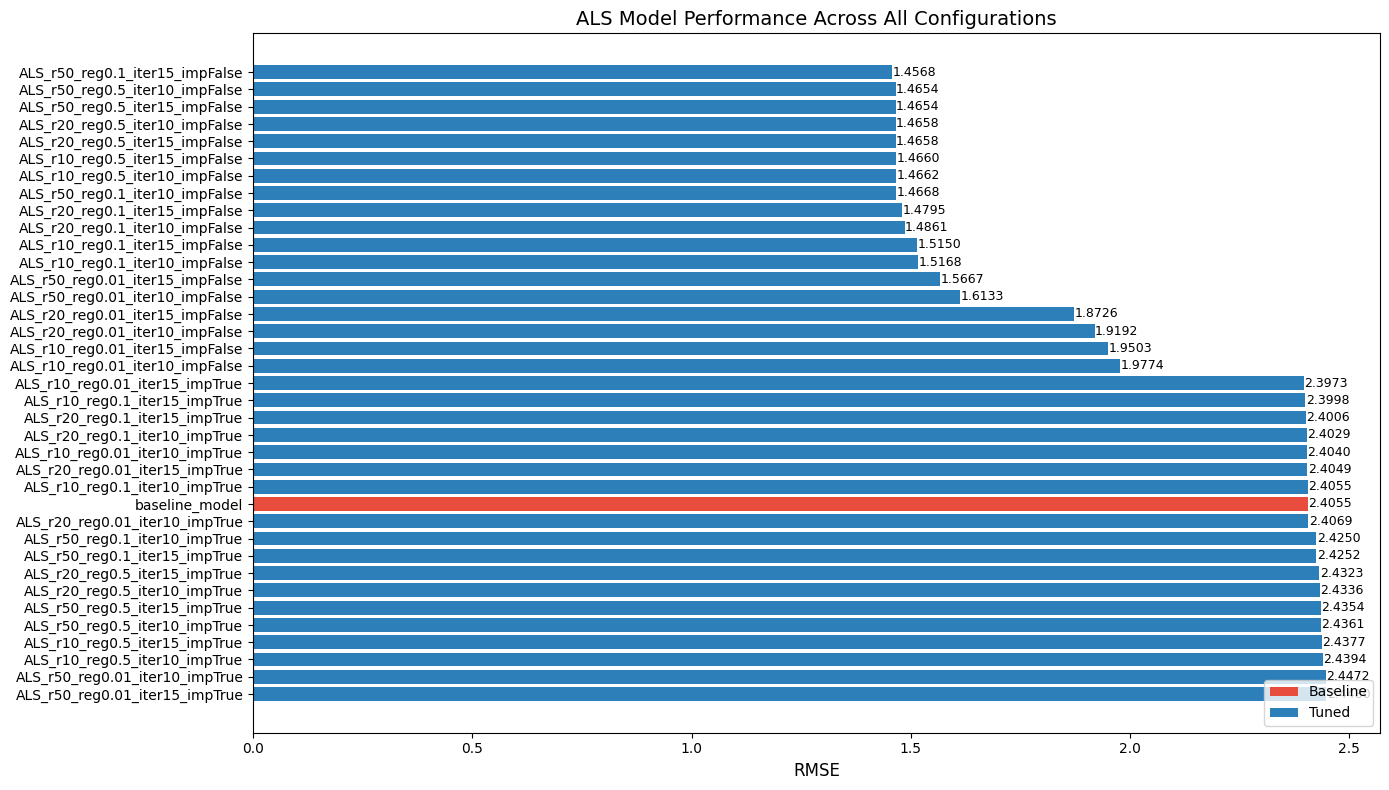

In [0]:
import matplotlib.pyplot as plt

# Pull all runs sorted by RMSE
runs = mlflow.search_runs(order_by=["metrics.rmse ASC"])
filtered = runs[runs["params.model_type"].isin(["baseline", "tuned"])]
filtered = filtered.sort_values("metrics.rmse")

# Build labels and colours
labels = filtered["tags.mlflow.runName"].tolist()
rmse_values = filtered["metrics.rmse"].tolist()
colours = ["#e74c3c" if name == "baseline_model" else "#2c7fb8" for name in labels] # color baseline model red and tuned models blue

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(labels, rmse_values, color=colours)
ax.set_xlabel("RMSE", fontsize=12)
ax.set_title("ALS Model Performance Across All Configurations", fontsize=14)
ax.invert_yaxis()

# Add value labels on bars
for bar, val in zip(bars, rmse_values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
            f"{val:.4f}", va="center", fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="Baseline"),
                   Patch(facecolor="#2c7fb8", label="Tuned")]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

### Conclusion

A collaborative filtering recommender system was built for Steam user-game interactions using Spark MLlib's ALS algorithm. Key design choices included using play hours rather than purchase data as the feedback signal — justified by the finding that nearly half of all purchases had no corresponding play record. Log transformation to compress the heavily skewed hours distribution (median 4.5 hours, maximum 11,754) was also applied.

Game IDs were generated using StringIndexer within Databricks rather than relying on the provided external CSV, and exploratory analysis revealed critical dataset characteristics: 99.8% matrix sparsity, 46% of users having played only a single game, and a 2:1 ratio of purchase to play records.

We established a baseline model (rank=10, regParam=0.1, maxIter=10, implicitPrefs=True) with RMSE=2.41, then systematically tuned 36 hyperparameter configurations across rank, regParam, maxIter, and implicitPrefs — all tracked via MLflow. The best model (rank=50, regParam=0.1, maxIter=15, implicitPrefs=False) achieved RMSE=1.4568, a substantial _**39.44%**_ improvement over the baseline (((2.4055-1.4568) / 2.4055) * 100).

A key finding was that explicit feedback mode outperformed implicit mode despite the data being technically implicit. This is because our log transformation converts raw play hours into a continuous scale that behaves like an explicit preference signal, allowing ALS to directly optimise for predicting these values rather than treating them as confidence weights on a binary preference. The explicit model also produced more diverse recommendations — surfacing strategy and management titles alongside FPS games for a user whose play history spanned both genres — whereas the implicit model tended toward over-specialisation.

Some Perceived Limitations: 
- RMSE measures point prediction accuracy rather than ranking quality. Metrics such as precision@k or NDCG would better evaluate whether the top-N recommendations are relevant. 
- A single train-test split was used; cross-validation (grid search or randomized search) would provide more robust estimates. 
- Finally, a hybrid approach blending collaborative filtering with content-based methods could address the over-specialisation observed in some recommendation sets.

### Acknowledgements

Dataset: [steam-200k](https://www.kaggle.com/datasets/tamber/steam-video-games) (user–game interaction data). Claude (Anthropic) was used as a documentation aid for `StringIndexer` and for debugging assistance during development.
